# Thyroid Disease — Shared Preprocessing Pipeline

This notebook is the **single source of truth** for data preprocessing used
by both the classical ML track (Random Forest, etc.) and the deep learning
track. Run this notebook once; it exports clean, encoded, scaled train/test
arrays plus the fitted preprocessing objects to `data/processed/`.

Downstream model notebooks should **load the exported files** instead of
re-doing any cleaning — that keeps every model in the comparison evaluated
on the exact same train/test split and feature space.

**Outputs written to `data/processed/`:**
- `X_train.csv`, `X_test.csv` — fully numeric, encoded, scaled feature matrices
- `y_train.csv`, `y_test.csv` — encoded integer labels
- `preprocessor.joblib` — fitted `ColumnTransformer` (imputers + scaler + one-hot)
- `label_encoder.joblib` — fitted `LabelEncoder` for the target
- `feature_names.json` — column names for `X_train.csv` / `X_test.csv`, in order
- `class_names.json` — `LabelEncoder` classes, in order (index = encoded label)
- `metadata.json` — shapes, dropped columns, split settings, random seed


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
TEST_SIZE = 0.20
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

OUTPUT_DIR = "data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)


Matplotlib is building the font cache; this may take a moment.


## 1. Load the raw dataset

Uses `ucimlrepo` to pull the dataset directly (id=102). If your network
blocks this, download `thyroid+disease.zip` manually from the UCI page and
point `RAW_CSV_PATH` at the extracted file instead — the fallback branch
below handles that.


In [4]:
RAW_CSV_PATH = "thyroid_dataset/allhypo.data"  # e.g. "data/raw/allhypo.data" if loading a raw file manually

df_manual = pd.read_csv(
    RAW_CSV_PATH,
    header=None,
    na_values="?"
)

X_raw = df_manual.iloc[:, :-1].copy()
y_raw = df_manual.iloc[:, [-1]].copy()
y_raw.columns = ["Class"]

print("Features shape:", X_raw.shape)
print("Targets shape:", y_raw.shape)


Features shape: (2800, 29)
Targets shape: (2800, 1)


## 2. Quick exploration

In [5]:
display(X_raw.head())
print()
print(X_raw.dtypes)


,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,41.0,F,f,f,f,f,f,f,f,f,...,2.5,t,125.0,t,1.14,t,109.0,f,NaN,SVHC
1,23.0,F,f,f,f,f,f,f,f,f,...,2.0,t,102.0,f,NaN,f,NaN,f,NaN,other
2,46.0,M,f,f,f,f,f,f,f,f,...,NaN,t,109.0,t,0.91,t,120.0,f,NaN,other
3,70.0,F,t,f,f,f,f,f,f,f,...,1.9,t,175.0,f,NaN,f,NaN,f,NaN,other
4,70.0,F,f,f,f,f,f,f,f,f,...,1.2,t,61.0,t,0.87,t,70.0,f,NaN,SVI



0     float64
1         str
2         str
3         str
4         str
5         str
6         str
7         str
8         str
9         str
10        str
11        str
12        str
13        str
14        str
15        str
16        str
17    float64
18        str
19    float64
20        str
21    float64
22        str
23    float64
24        str
25    float64
26        str
27    float64
28        str
dtype: object


In [6]:
target_col = y_raw.columns[0]
print("Target column:", target_col)
y_raw[target_col].value_counts(dropna=False)


Target column: Class


Class
negative.|3733    1
negative.|1442    1
negative.|2965    1
negative.|806     1
negative.|2807    1
                 ..
negative.|3689    1
negative.|3652    1
negative.|1287    1
negative.|3496    1
negative.|724     1
Name: count, Length: 2800, dtype: int64

In [7]:
missing_pct = X_raw.isna().mean().sort_values(ascending=False) * 100
missing_pct[missing_pct > 0]


27    100.000000
19     20.892857
23     10.607143
25     10.535714
17     10.142857
21      6.571429
1       3.928571
0       0.035714
dtype: float64

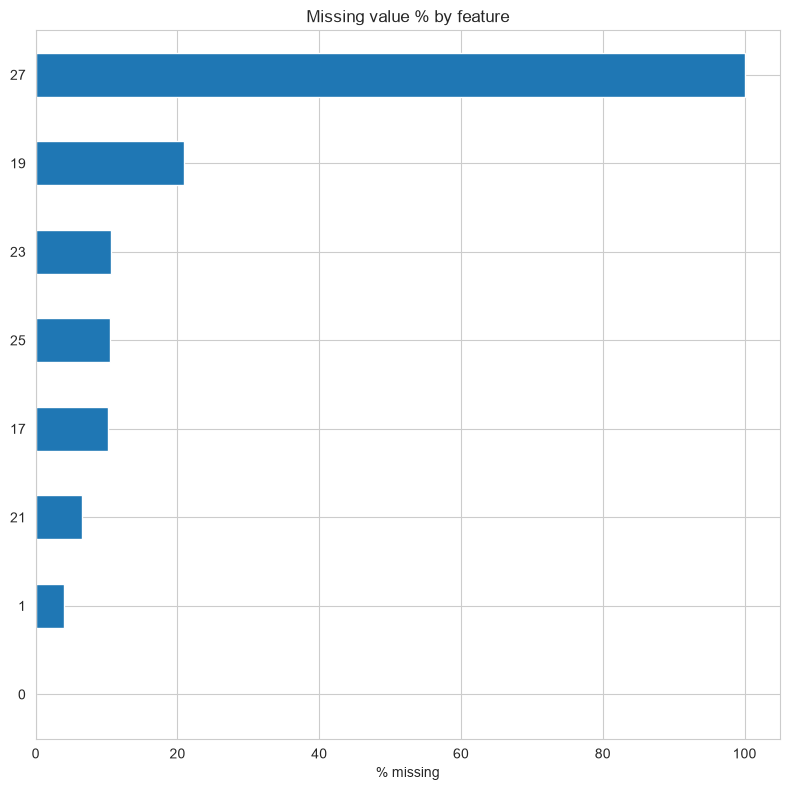

In [8]:
plt.figure(figsize=(8, 8))
missing_pct[missing_pct > 0].sort_values().plot(kind="barh")
plt.title("Missing value % by feature")
plt.xlabel("% missing")
plt.tight_layout()
plt.show()


## 3. Clean the target

Some UCI thyroid files encode compound labels like `"hypothyroid.|3733"` —
strip anything after `.` or `|` so we're left with a clean diagnosis label,
then label-encode it. The fitted `LabelEncoder` is exported so any model
notebook can decode predictions back to human-readable class names.


In [9]:
y_clean = y_raw[target_col].astype(str).str.split(r"[.|]").str[0].str.strip()
y_clean = y_clean.replace({"": "unknown"})
print(y_clean.value_counts())

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_clean)

class_names = list(label_encoder.classes_)
print("\nClasses (index = encoded label):", class_names)


Class
negative                   2580
compensated hypothyroid     154
primary hypothyroid          64
secondary hypothyroid         2
Name: count, dtype: int64

Classes (index = encoded label): ['compensated hypothyroid', 'negative', 'primary hypothyroid', 'secondary hypothyroid']


## 4. Drop near-empty columns

Columns missing in more than `MISSING_THRESHOLD` of rows (e.g. `TBG` is
missing in nearly every row of the combined file) are dropped. This is
threshold-based rather than hardcoded by name, so it stays correct even if
the exact column set differs from what's expected.


In [16]:
MISSING_THRESHOLD = 0.90  # drop columns missing in >90% of rows
dropped_columns = missing_pct[missing_pct > MISSING_THRESHOLD * 100].index.tolist()
print("Dropping near-empty columns:", dropped_columns)

X = X_raw.drop(columns=dropped_columns)
X.columns = range(X.shape[1])


Dropping near-empty columns: [27]


## 5. Identify numeric vs categorical columns

In [17]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: [0, 17, 19, 21, 23, 25]
Categorical columns: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 20, 22, 24, 26, 27]


## 6. Train/test split — **before** fitting the preprocessor

Splitting first and fitting the imputer/scaler/encoder only on the training
set avoids leaking test-set statistics (medians, means, categories) into
training, which would give overly optimistic evaluation numbers later.


In [18]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train_raw.shape, " Test shape:", X_test_raw.shape)


Train shape: (2240, 28)  Test shape: (560, 28)


## 7. Build and fit the shared preprocessing pipeline

- **Numeric**: median imputation + `StandardScaler` (scaling matters for the
  DL track; it's harmless for Random Forest / tree models since they're
  scale-invariant, so one shared pipeline works for both).
- **Categorical**: most-frequent imputation + one-hot encoding.

The `ColumnTransformer` is fit **only on the training data**, then used to
transform both train and test — this is the exact object exported for reuse.


In [20]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])

X_train_enc = preprocessor.fit_transform(X_train_raw)
X_test_enc = preprocessor.transform(X_test_raw)

# Densify if the ColumnTransformer returned a sparse matrix (common when one-hot is involved)
if hasattr(X_train_enc, "toarray"):
    X_train_enc = X_train_enc.toarray()
    X_test_enc = X_test_enc.toarray()

print("Encoded train shape:", X_train_enc.shape)
print("Encoded test shape:", X_test_enc.shape)


Encoded train shape: (2240, 51)
Encoded test shape: (560, 51)


In [22]:
cat_feature_names = (
    list(
        preprocessor.named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out([str(c) for c in categorical_cols])
    )
    if categorical_cols else []
)

feature_names = [str(c) for c in numeric_cols] + cat_feature_names

print(f"Total features after encoding: {len(feature_names)}")

Total features after encoding: 51


## 8. Assemble final DataFrames

In [23]:
X_train_df = pd.DataFrame(X_train_enc, columns=feature_names, index=X_train_raw.index)
X_test_df = pd.DataFrame(X_test_enc, columns=feature_names, index=X_test_raw.index)

y_train_df = pd.DataFrame({"target": y_train}, index=X_train_raw.index)
y_test_df = pd.DataFrame({"target": y_test}, index=X_test_raw.index)

display(X_train_df.head())


,0,17,19,21,23,25,1_F,1_M,2_f,2_t,...,22_f,22_t,24_f,24_t,26_f,27_STMW,27_SVHC,27_SVHD,27_SVI,27_other
1965,0.723549,-0.166171,0.494407,-0.636171,0.502365,-0.971098,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
914,-0.380373,-0.200617,-0.179156,-0.024646,0.232038,-0.234546,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
2286,1.299508,-0.103018,-0.044443,-0.141127,-0.092356,-0.106450,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1033,-0.908336,-0.137465,-0.313868,-0.490570,-0.849273,-0.010378,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
1894,-1.292309,-0.160429,-0.583293,-0.898254,-0.633011,-0.682882,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


## 9. Export everything

Both the ML and DL notebooks should load from `data/processed/` instead of
touching the raw dataset — that guarantees they train/evaluate on identical
data.


In [24]:
# Feature/label CSVs — ready to feed straight into sklearn or a DL framework
X_train_df.to_csv(os.path.join(OUTPUT_DIR, "X_train.csv"), index=False)
X_test_df.to_csv(os.path.join(OUTPUT_DIR, "X_test.csv"), index=False)
y_train_df.to_csv(os.path.join(OUTPUT_DIR, "y_train.csv"), index=False)
y_test_df.to_csv(os.path.join(OUTPUT_DIR, "y_test.csv"), index=False)

# Fitted transformer + label encoder, so any notebook can preprocess new/raw
# data the exact same way, or decode predictions back to class names
joblib.dump(preprocessor, os.path.join(OUTPUT_DIR, "preprocessor.joblib"))
joblib.dump(label_encoder, os.path.join(OUTPUT_DIR, "label_encoder.joblib"))

with open(os.path.join(OUTPUT_DIR, "feature_names.json"), "w") as f:
    json.dump(feature_names, f, indent=2)

with open(os.path.join(OUTPUT_DIR, "class_names.json"), "w") as f:
    json.dump(class_names, f, indent=2)

metadata = {
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "missing_threshold": MISSING_THRESHOLD,
    "dropped_columns": dropped_columns,
    "numeric_columns": numeric_cols,
    "categorical_columns": categorical_cols,
    "n_features_after_encoding": len(feature_names),
    "train_shape": list(X_train_df.shape),
    "test_shape": list(X_test_df.shape),
    "class_names": class_names,
}
with open(os.path.join(OUTPUT_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Exported all artifacts to '{OUTPUT_DIR}/':")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", fname)


Exported all artifacts to 'data/processed/':
 - X_test.csv
 - X_train.csv
 - class_names.json
 - feature_names.json
 - label_encoder.joblib
 - metadata.json
 - preprocessor.joblib
 - y_test.csv
 - y_train.csv


### Next steps

- Point the Random Forest notebook (and the DL notebook) at
  `data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`.
- Use `class_names.json` to decode predicted integer labels back to
  diagnosis names in evaluation reports.
- Re-run *this* notebook only — never re-derive train/test splits inside a
  model notebook — if the cleaning logic ever changes, so every model stays
  comparable on identical data.
